# Mutual Information

Plotting some graphics comparing mutual information present between various features

In [2]:
# Imports
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import imageio
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import sys
import os
sys.path.append(os.path.abspath('..'))
from venus_ml import VenusDataset

## Dataset Setup

In [3]:
def get_features(names, mean=True, std=False):
    out_list = []
    for name in names:
        if mean:
            out_list.append(name + "_mean")
        if std:
            out_list.append(name + "_std")
    return out_list

requested_dict = {
    'k18_fw_mean': [1.4e3, 'Watts'],
    'g28_fw_mean': [4.3e3, 'Watts'],
    'inj_i_mean': [185, 'Amps'],
    'ext_i_mean': [137, 'Amps'],
    'mid_i_mean': [153, 'Amps'],
    'sext_i_mean': [430, 'Amps'],
    'extraction_v_mean': [20, 'kV'],
    'puller_v_mean': [2, 'kV'],
}

requested_features = list(requested_dict.keys())

feature_groups = {
    "S": ["inj_mbar", "bias_v", "bias_i", "extraction_i"],
    "M": ["inj_mbar", "bias_v", "bias_i", "extraction_i", "ext_mbar", "k18_fw", "k18_ref", "g28_fw", "puller_i"],
    "L": ["inj_mbar", "bias_v", "bias_i", "extraction_i", "ext_mbar", "k18_fw", "k18_ref", "g28_fw", "puller_i", "inj_i", "ext_i", "mid_i", "sext_i", "x_ray_source", "x_ray_exit"],
}

In [4]:
config = {
    "file_path": "../data/acc_watch_data.parquet",
    "input_columns": [],
    "output_columns": [],
}



dataset = VenusDataset(**config)
df = dataset.df
print(df.shape)

(29290, 170)


## Graph Helper Functions


In [5]:
from sklearn.feature_selection import mutual_info_regression

def plot_mi_heatmap(df, column_names, run_id=None, title=None, x_label=None, y_label=None, save_image=False):
    """
    Plots a heatmap of pairwise mutual information between features.

    Parameters:
    - df: pandas DataFrame
    - column_names: list of column names to include in the MI calculation
    - run_id: optional, if provided, filters the dataframe to only include data with this run_id
    - title: optional, title of the plot
    - x_label: optional, label for the x-axis
    - y_label: optional, label for the y-axis
    """
    # Filter dataframe if run_id is provided
    if run_id is not None:
        df = df[df['run_id'] == run_id]

    # Select only the columns of interest
    data = df[column_names].dropna()

    # Initialize an empty DataFrame to store MI values
    mi_matrix = pd.DataFrame(index=column_names, columns=column_names)

    # Compute pairwise MI values
    for i in column_names:
        for j in column_names:
            if i == j:
                mi = np.nan  # Or set to 0
            else:
                x = data[i].values.reshape(-1, 1)
                y = data[j].values
                mi = mutual_info_regression(x, y, discrete_features=False)
                mi = mi[0]
            mi_matrix.loc[i, j] = mi

    # Convert MI matrix to float
    mi_matrix = mi_matrix.astype(float)

    # Plot heatmap
    plt.style.use('dark_background')
    plt.figure(figsize=(10, 8))
    sns.heatmap(mi_matrix, annot=True, fmt=".2f", cmap='viridis')
    plt.title(title if title else 'Pairwise Mutual Information Heatmap')
    plt.xlabel(x_label if x_label else 'Features')
    plt.ylabel(y_label if y_label else 'Features')
    
    if save_image:
        output_dir = "presentation_plots"
        os.makedirs(output_dir, exist_ok=True)
        file_path = os.path.join(output_dir, f"{title.replace(' ', '_').lower()}.png")
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
        
    plt.show()

def plot_mi_barplot_over_runs(df, column_x, column_y, title=None, x_label=None, y_label=None, save_image=False):
    """
    Calculates the MI values between two columns for each unique run_id,
    and plots them on a bar plot to compare MI over runs.

    Parameters:
    - df: pandas DataFrame
    - column_x: name of the first column
    - column_y: name of the second column
    - title: optional, title of the plot
    - x_label: optional, label for the x-axis
    - y_label: optional, label for the y-axis
    - save_image: optional, if True saves the plot as an image
    """
    mi_values = []
    run_ids = df['run_id'].unique()

    for run_id in run_ids:
        df_run = df[df['run_id'] == run_id]
        df_run = df_run[[column_x, column_y]].dropna()
        if df_run.empty:
            continue
        x = df_run[column_x].values.reshape(-1, 1)
        y = df_run[column_y].values
        mi = mutual_info_regression(x, y, discrete_features=False)
        mi_values.append({'run_id': run_id, 'MI': mi[0]})

    mi_df = pd.DataFrame(mi_values)

    # Sort the data by run_id for consistent plotting
    mi_df.sort_values('run_id', inplace=True)

    # Plot bar plot
    plt.style.use('dark_background')
    plt.figure(figsize=(12, 6))

    sns.barplot(x='run_id', y='MI', data=mi_df, color='steelblue')

    plt.title(title if title else f'Mutual Information between {column_x} and {column_y} over Runs')
    plt.ylim(0, 2)
    plt.xlabel(x_label if x_label else 'Run ID')
    plt.ylabel(y_label if y_label else 'Mutual Information')
    plt.xticks(rotation=45)

    if save_image:
        output_dir = "presentation_plots"
        os.makedirs(output_dir, exist_ok=True)
        # Ensure title is provided and replace spaces for filename
        file_title = title if title else f'Mutual Information between {column_x} and {column_y} over Runs'
        file_path = os.path.join(output_dir, f"{file_title.replace(' ', '_').lower()}.png")
        plt.savefig(file_path, dpi=300, bbox_inches='tight')

    plt.show()

def plot_mi_variance_over_runs(df, feature_pairs, title=None, x_label=None, y_label=None):
    """
    Visualizes the variance of MI scores across runs for different feature pairs.

    Parameters:
    - df: pandas DataFrame
    - feature_pairs: list of tuples, each tuple contains two column names representing a feature pair
    - title: optional, title of the plot
    - x_label: optional, label for the x-axis
    - y_label: optional, label for the y-axis
    """
    mi_stats = []
    run_ids = df['run_id'].unique()

    for pair in feature_pairs:
        mi_values = []
        for run_id in run_ids:
            df_run = df[df['run_id'] == run_id]
            df_run = df_run[list(pair)].dropna()
            if df_run.empty:
                continue
            x = df_run[pair[0]].values.reshape(-1, 1)
            y = df_run[pair[1]].values
            mi = mutual_info_regression(x, y, discrete_features=False)
            mi_values.append(mi[0])
        if mi_values:
            mi_mean = np.mean(mi_values)
            mi_std = np.std(mi_values)
            mi_stats.append({'Feature Pair': f'{pair[0]} & {pair[1]}', 'Mean MI': mi_mean, 'Std MI': mi_std})

    mi_stats_df = pd.DataFrame(mi_stats)

    # Plot bar plot with error bars
    plt.style.use('dark_background')
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Feature Pair', y='Mean MI', yerr=mi_stats_df['Std MI'], data=mi_stats_df, capsize=0.2)
    plt.title(title if title else 'Variance of MI Scores Across Runs for Feature Pairs')
    plt.xlabel(x_label if x_label else 'Feature Pairs')
    plt.ylabel(y_label if y_label else 'Mean Mutual Information')
    plt.xticks(rotation=45)
    plt.show()


## Visualizations

In [6]:
total = list(set(get_features(feature_groups["M"]) + requested_features)) + ["fcv1_i_mean"]
print(len(total), total)

16 ['extraction_i_mean', 'ext_mbar_mean', 'ext_i_mean', 'k18_fw_mean', 'bias_i_mean', 'k18_ref_mean', 'mid_i_mean', 'sext_i_mean', 'inj_mbar_mean', 'inj_i_mean', 'g28_fw_mean', 'puller_v_mean', 'puller_i_mean', 'bias_v_mean', 'extraction_v_mean', 'fcv1_i_mean']


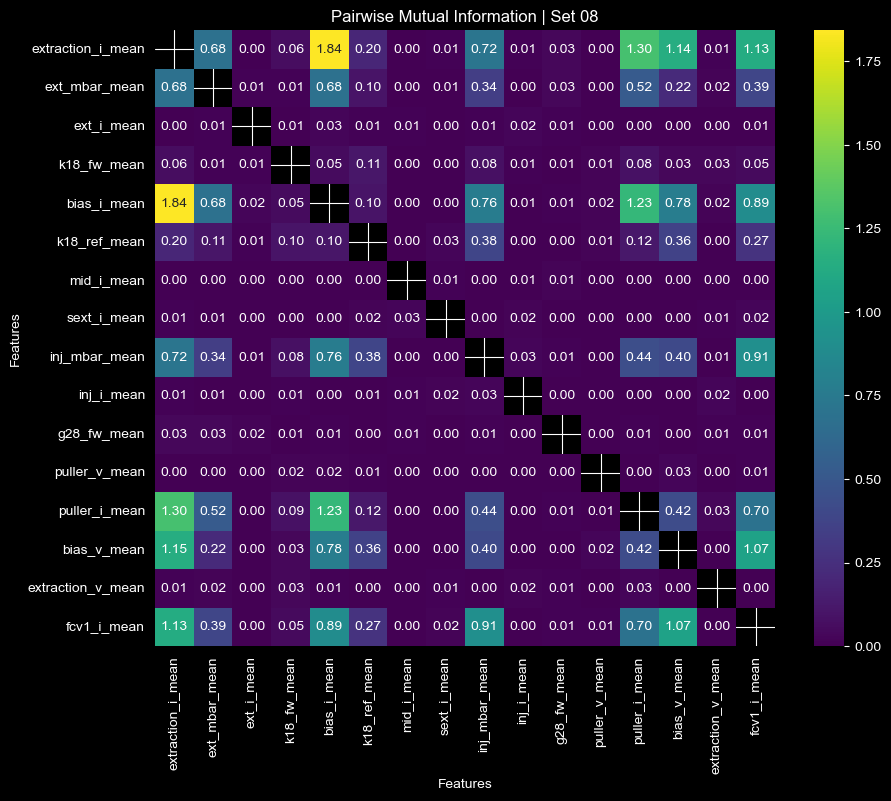

In [14]:
set_df = df[df['run_id'] == '08']
plot_mi_heatmap(set_df, total, save_image=True, title='Pairwise Mutual Information | Set 08')

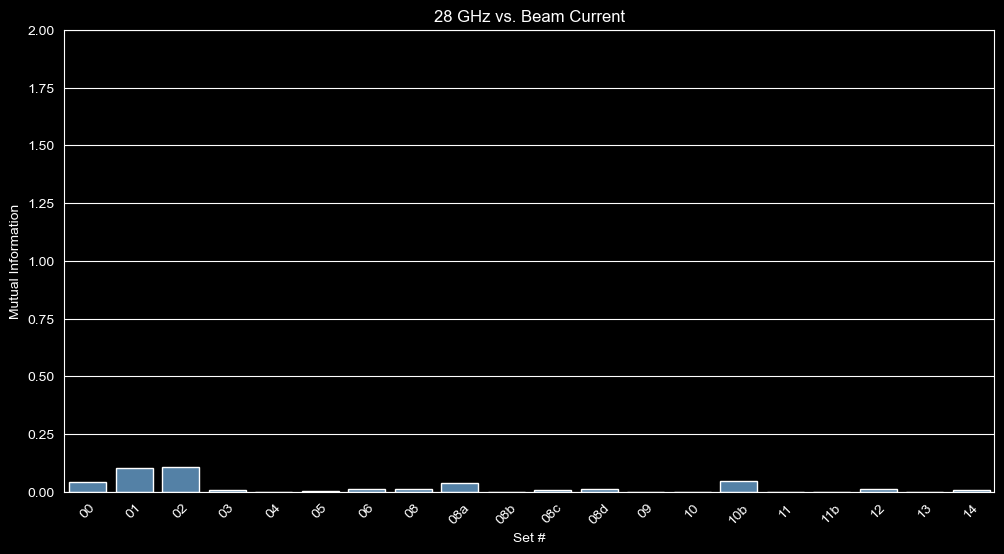

In [8]:
plot_mi_barplot_over_runs(df, "g28_fw_mean", "fcv1_i_mean", title="28 GHz vs. Beam Current", x_label="Set #", y_label=None, save_image=True)

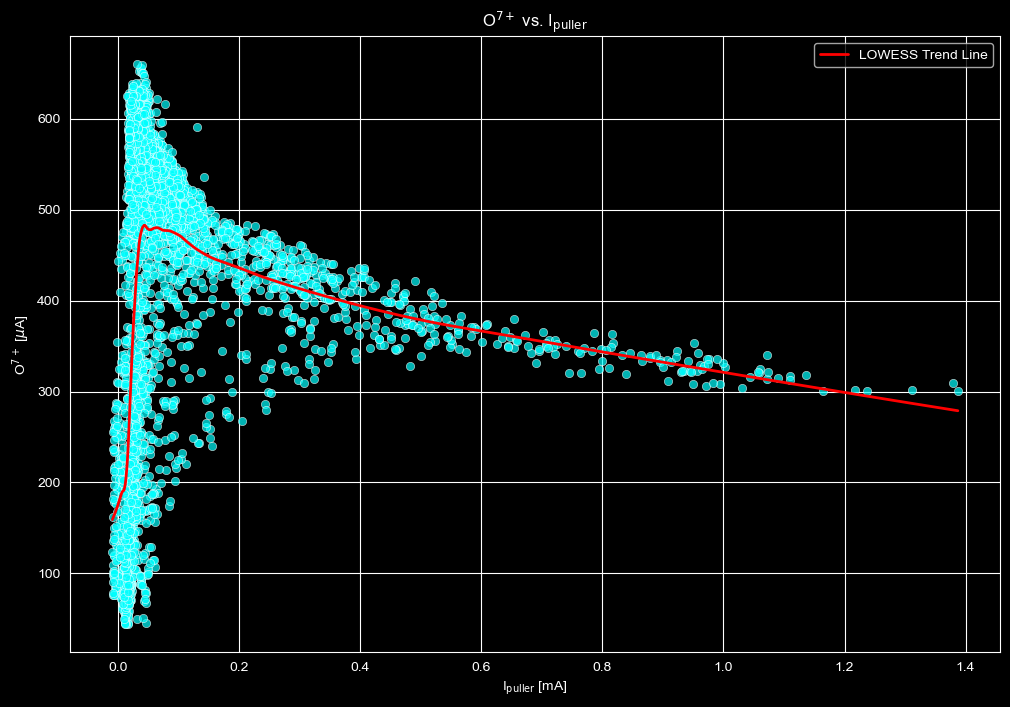

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
import os

def plot_scatter_with_nonlinear_trendline(
    df,
    column_x,
    column_y,
    run_id=None,
    input_scale=1,
    output_scale=1,
    title=None,
    x_label=None,
    y_label=None,
    save_image=False
):
    """
    Plots a scatter plot of two features with a non-linear trend line using LOWESS smoothing.
    
    Parameters:
    - df: pandas DataFrame
    - column_x: name of the input feature (x-axis)
    - column_y: name of the output feature (y-axis)
    - run_id: optional, if provided, filters the DataFrame to only include data with this run_id
    - input_scale: optional, scaling factor to multiply the input feature (default is 1)
    - output_scale: optional, scaling factor to multiply the output feature (default is 1)
    - title: optional, title of the plot
    - x_label: optional, label for the x-axis
    - y_label: optional, label for the y-axis
    - save_image: optional, if True saves the plot as an image
    """
    # Filter dataframe if run_id is provided
    if run_id is not None:
        df = df[df['run_id'] == run_id]

    # Ensure the data is without NaN values
    data = df[[column_x, column_y]].dropna()
    
    # Check if data is empty after filtering
    if data.empty:
        print(f"No data available for run_id {run_id} with columns {column_x} and {column_y}.")
        return

    # Apply scaling to input and output features
    data[column_x] = data[column_x] * input_scale
    data[column_y] = data[column_y] * output_scale

    # Set the style
    plt.style.use('dark_background')
    plt.figure(figsize=(12, 8))
    
    # Scatter plot
    sns.scatterplot(
        x=column_x,
        y=column_y,
        data=data,
        color='cyan',
        edgecolor='white',
        alpha=0.7
    )
    
    # Prepare data for LOWESS smoothing
    x = data[column_x].values
    y = data[column_y].values
    
    # Fit LOWESS model
    lowess_smoothed = lowess(y, x, frac=0.3, it=0, return_sorted=True)
    
    # Plot the trend line
    plt.plot(
        lowess_smoothed[:, 0],
        lowess_smoothed[:, 1],
        color='red',
        linewidth=2,
        label='LOWESS Trend Line'
    )
    
    # Set labels and title
    plt.title(title if title else f'Scatter Plot of {column_x} vs {column_y} with Non-linear Trend Line')
    plt.xlabel(x_label if x_label else column_x)
    plt.ylabel(y_label if y_label else column_y)
    
    # Add legend
    plt.legend()
    
    # Save the image if required
    if save_image:
        output_dir = "presentation_plots"
        os.makedirs(output_dir, exist_ok=True)
        # Generate a filename based on the title or column names
        file_title = title if title else f'Scatter Plot of {column_x} vs {column_y}'
        if run_id is not None:
            file_title += f' (Run {run_id})'
        file_path = os.path.join(output_dir, f"{file_title.replace(' ', '_').lower()}.png")
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
    
    plt.show()



plot_scatter_with_nonlinear_trendline(df, "puller_i_mean", "fcv1_i_mean", run_id="08", title="O$^{7+}$ vs. I$_\mathrm{puller}$", x_label="I$_\mathrm{puller}$ [mA]", y_label="O$^{7+}$ [$\mu$A]", save_image=True, output_scale=1e6)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import os

def compare_model_generalization_with_scaling(
    df,
    input_features,
    output_feature,
    scaling_method,
    train_run_id,
    val_run_id,
    title=None,
    x_label='Sample Index',
    y_label='Output Value',
    save_image=False
):
    """
    Compares model generalization with and without scaling the validation output.

    Parameters:
    - df: pandas DataFrame containing the data.
    - input_features: list of input feature column names.
    - output_feature: name of the output feature column.
    - scaling_method: 'min-max' or 'standardization'.
    - train_run_id: run_id used for training data.
    - val_run_id: run_id used for validation data.
    - title: optional, title of the plot.
    - x_label: optional, label for the x-axis.
    - y_label: optional, label for the y-axis.
    - save_image: optional, if True saves the plot as an image.
    """
    # Filter data for training and validation sets
    train_df = df[df['run_id'] == train_run_id]
    val_df = df[df['run_id'] == val_run_id]

    # Ensure there are no NaN values
    train_df = train_df[input_features + [output_feature]].dropna()
    val_df = val_df[input_features + [output_feature]].dropna()

    # Separate inputs and outputs
    X_train = train_df[input_features]
    y_train = train_df[output_feature].values.reshape(-1, 1)

    X_val = val_df[input_features]
    y_val = val_df[output_feature].values.reshape(-1, 1)

    # Initialize the scaler based on the scaling method
    if scaling_method == 'min-max':
        scaler = MinMaxScaler()
    elif scaling_method == 'standardization':
        scaler = StandardScaler()
    else:
        raise ValueError("Invalid scaling_method. Choose 'min-max' or 'standardization'.")

    # Fit the scaler on the training output
    scaler.fit(y_train)

    # Scale the validation output to match training output distribution
    y_val_scaled = scaler.transform(y_val)

    # Create two versions of y_val: scaled and unscaled
    y_true_scaled = y_val_scaled.ravel()      # Scaled validation output
    y_true_unscaled = y_val.ravel()           # Original validation output

    # Train the Random Forest model on the training data
    model = RandomForestRegressor(random_state=42)
    model.fit(X_train, y_train.ravel())

    # Predict on the validation data
    y_pred_scaled = model.predict(X_val)
    y_pred_unscaled = y_pred_scaled.copy()  # Same predictions for both cases

    # Compute R^2 scores
    r2_scaled = r2_score(y_true_scaled, y_pred_scaled)
    r2_unscaled = r2_score(y_true_unscaled, y_pred_unscaled)

    # Sort the true values and rearrange predictions accordingly for scaled data
    sorted_indices_scaled = np.argsort(y_true_scaled)
    y_true_scaled_sorted = y_true_scaled[sorted_indices_scaled]
    y_pred_scaled_sorted = y_pred_scaled[sorted_indices_scaled]

    # Sort the true values and rearrange predictions accordingly for unscaled data
    sorted_indices_unscaled = np.argsort(y_true_unscaled)
    y_true_unscaled_sorted = y_true_unscaled[sorted_indices_unscaled]
    y_pred_unscaled_sorted = y_pred_unscaled[sorted_indices_unscaled]

    # Generate sample indices for plotting
    indices_scaled = np.arange(len(y_true_scaled_sorted))
    indices_unscaled = np.arange(len(y_true_unscaled_sorted))

    # Plot side-by-side scatter plots
    plt.style.use('dark_background')
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    # Scaled plot
    axs[0].scatter(indices_scaled, y_true_scaled_sorted, label='True Values', color='cyan', edgecolor='white', alpha=0.7)
    axs[0].scatter(indices_scaled, y_pred_scaled_sorted, label='Predicted Values', color='red', edgecolor='white', alpha=0.7)
    axs[0].set_title(f'Scaled Output (R² = {r2_scaled:.3f})')
    axs[0].set_xlabel(x_label)
    axs[0].set_ylabel(y_label)
    axs[0].legend()

    # Unscaled plot
    axs[1].scatter(indices_unscaled, y_true_unscaled_sorted, label='True Values', color='cyan', edgecolor='white', alpha=0.7)
    axs[1].scatter(indices_unscaled, y_pred_unscaled_sorted, label='Predicted Values', color='red', edgecolor='white', alpha=0.7)
    axs[1].set_title(f'Unscaled Output (R² = {r2_unscaled:.3f})')
    axs[1].set_xlabel(x_label)
    axs[1].set_ylabel(y_label)
    axs[1].legend()

    # Overall title
    if title:
        fig.suptitle(title, fontsize=16)

    # Adjust layout
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Save the image if required
    if save_image:
        output_dir = "presentation_plots"
        os.makedirs(output_dir, exist_ok=True)
        file_title = title if title else 'Model Generalization Comparison'
        file_path = os.path.join(output_dir, f"{file_title.replace(' ', '_').lower()}.png")
        plt.savefig(file_path, dpi=300, bbox_inches='tight')

    plt.show()

    # Print R^2 scores
    print(f"R² score with scaled output: {r2_scaled:.3f}")
    print(f"R² score with unscaled output: {r2_unscaled:.3f}")


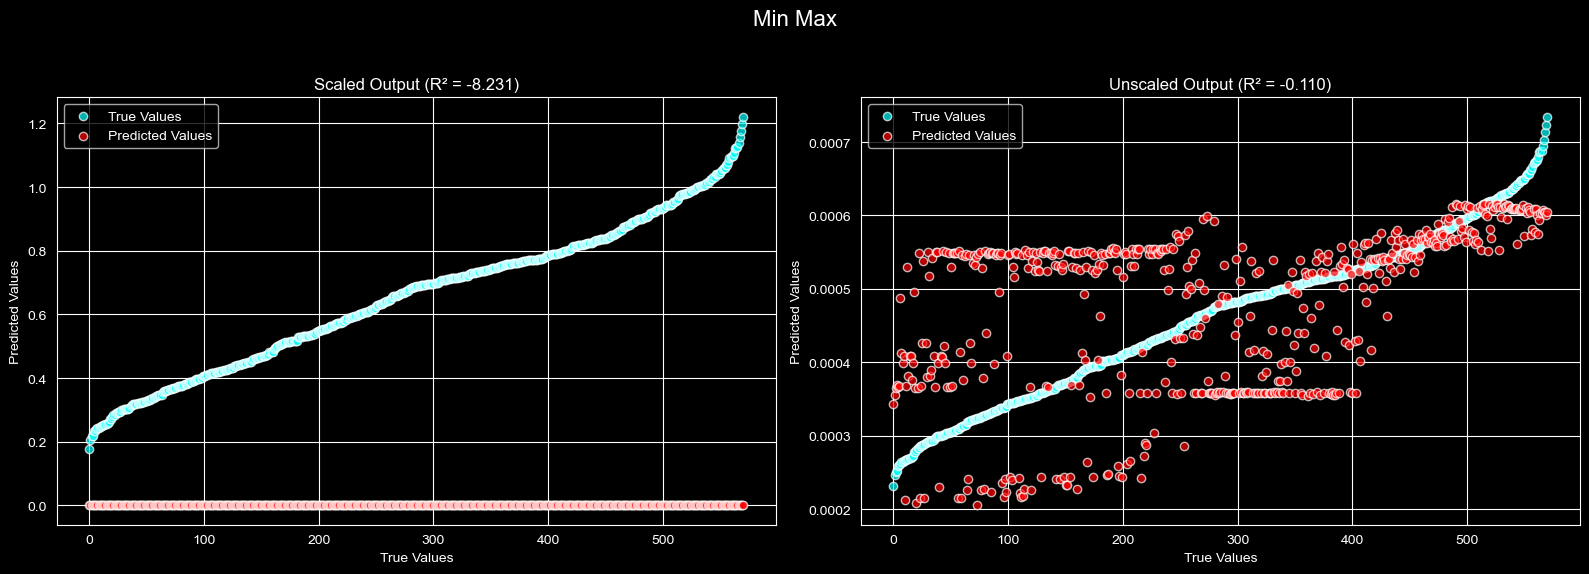

R² score with scaled output: -8.231
R² score with unscaled output: -0.110


In [11]:
compare_model_generalization_with_scaling(df, get_features(feature_groups["S"]), "fcv1_i_mean", scaling_method="min-max", train_run_id="00", val_run_id="11", title="Min Max", x_label="True Values", y_label="Predicted Values",)